### Contribution Report
| Student name | Tasks | Id | الشعبة |
| :--- | :--- | ---: | :--- |
|خديجة عزيز | The Methods (add_length,describe,analysis_corr,plot_for_corr), Column Descriptors,Contribution Report, finding the dataset , presentation | 4552542 | F3 | 
|نورهان كاتب | The Methods (_ensure_text_and_wordcount,plot_sentiment_count,plot_top_entities,plot_wordcount_histogram,plot_boxplot_by_sentiment,plot_sentiment_pie,plot_wordcloud,visualize_all), presentation | 4553896 | F4 |
|ريما السحيمي | The Methods (sentiment_distrbution,top_entitie,word_frequency,negative_sentiment_ratio,sentiment_average,eda), presentation | 4553889 | F4 |
|شهد الحجيلي | The Methods (__init_,summary,clean_text,clean_dataset), the import, create an object from class, presentation | 4551942 | F3 |

# Dataset: The Dataset that has been used is a CSV file named twitter_training.csv which contains Data about sentiment of tweets. It contains the following columns:
- **id(before was unclear 2401)**: This column represents the id for each tweet
- **entity(before was unclear Borderlands)**:This column represents the entity mention in the tweet
- **sentiment (before was unclear Positive)**: This column represents the sentiment of each tweet(positive, negative, neutral, irrelevant) which could be usefull for analysis and several plot 
- **text(before was unclear text I am coming to the borders and I will kill you)**: This column represents the text of the tweet         


In [20]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [21]:
# Import libraries
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter 

In [22]:
class TwitterSentimentAnalyzer:

    def __init__(self, file_path):
        """Load dataset and initialize object."""
        self.df = pd.read_csv(file_path)

    # -------------------------------------------------
    def summary(self):
        """Show basic summary of the raw dataset before cleaning."""

        print("\n🔹 Dataset Shape:", self.df.shape)

        print("\n🔹 Columns:", self.df.columns.tolist())

        print("\n🔹 First 5 Rows:\n", self.df.head())

        print("\n🔹 Number of Missing Values:\n", self.df.isnull().sum())

        print("\n🔹 Number of Duplicated Rows:", self.df.duplicated().sum())

        print("\n🔹 Dataset Info:")
        print(self.df.info())

        # Missing values heatmap
        plt.figure(figsize=(6, 4))
        sns.heatmap(self.df.isnull())
        plt.title("Missing Values Heatmap")
        plt.show()

    # -------------------------------------------------
    def clean_text(self, text):
        """
        Clean a single tweet text:
        - Remove URLs
        - Remove mentions
        - Remove emojis   (optional)
        - Remove hashtags (# but keep word)
        - Remove punctuation
        - Convert to lowercase
        - Strip spaces
        """
        text = str(text)

        # Remove URLs
        text = re.sub(r"http\S+|www.\S+", "", text)

        # Remove mentions
        text = re.sub(r"@\w+", "", text)

        # Remove hashtag symbol only
        text = re.sub(r"#[A-Za-z0-9_]+", lambda m: m.group(0)[1:], text)

        # Remove punctuation
        text = re.sub(r"[^A-Za-z0-9\s]", "", text)

        # Normalize
        text = text.lower().strip()

        return text

    # -------------------------------------------------
    def clean_dataset(self):
        """
        Clean entire dataset:
        - Rename columns
        - Remove duplicates
        - Remove null text
        - Normalize sentiment column
        - Apply text cleaning
        - Remove empty cleaned text rows
        """

        # Rename columns
        self.df.columns = ["id", "entity", "sentiment", "text"]

        # Remove duplicates
        self.df = self.df.drop_duplicates()

        # Remove rows with missing text
        self.df = self.df[self.df["text"].notna()]

        # Normalize sentiment
        self.df["sentiment"] = (
            self.df["sentiment"].astype(str).str.lower().str.strip()
        )

        # Apply text cleaning
        self.df["clean_text"] = self.df["text"].apply(self.clean_text)

        # Remove empty clean_text rows
        self.df = self.df[self.df["clean_text"] != ""]

        # Reset index
        self.df = self.df.reset_index(drop=True)
        
        return self.df


    #add a new columns for length by all characters and words only
    def add_length(self):
        """
        add columns length of clean_text:
        1-length_all: number of all characters
        2-length_words: number of words
        """
        # all 
        self.df["length_all"] = self.df["clean_text"].apply(len)

        # words 
        self.df["length_words"] = self.df["clean_text"].str.split().apply(len)

        return self.df

    # -----------------------------------------------

    """Analysis Methods"""
    
    def sentiment_distrbution(self):
        #counts how many times a sentiment appears
        return self.df["sentiment"].value_counts()


    def top_entities(self, n = 10):
        #Returns the top 10 most frequently mentioned entities
        return self.df["entity"].value_counts().head(n)

    def word_frequency(self, n = 10):
        #combining strings and split them into words
        words = " ".join(self.df["clean_text"]).split()

        #Returns the 10 most common words and times of appearing
        return Counter(words).most_common(n)

    def negative_sentiment_ratio(self):
        #Calculate negative sentiment ratio per entity 
        result = {}

        for entity in self.df["entity"].unique():
            #Filter rows for the current entity
            entity_rows = self.df[self.df["entity"] == entity]

            total = len(entity_rows)
            negative = len(entity_rows[entity_rows["sentiment"] == "negative"])

            result[entity] = f"{negative / total:.2f}"

        return result


    def sentiment_average(self):
        #Assigning numerical values for the sentiment labels
        score_map = {
            "positive" : 1,
            "neutral" : 0,
            "irrelevant" : 0,
            "negative" : -1
        }

        scores = self.df["sentiment"].map(score_map)
        avg = scores.mean()
        if avg > 0:
            print(f"{avg:.2f}\nOvarall sentiment is slightly positive! ")
        elif avg < 0:
            print(f"{avg:.2f}\nOvarall sentiment is slightly negative! ")
        else:
            print(f"{avg:.2f}\nOvarall sentiment is neutral! ")

    def describe(self):
        # to describe the tweet length words of sentiment
        describe = self.df.groupby("sentiment")["length_words"].describe()

        print(f"the describe of length words in sentiment{describe}")


    def analysis_corr(self):
        # to find the correlation between length words and sentiment
        scores_map = {
            "positive": 1,
            "neutral":0,
            "irrelevant": 0,
            "negative": -1
        }

        score = self.df["sentiment"].map(scores_map)   
        correlation = self.df["length_words"].corr(score)

        print(f" the correlation between length words and sentiment : {correlation:.2f}")
       
         
    # -------------------------------------------------

    def eda(self):
        print("Sentiment distribution:")
        print(self.sentiment_distrbution(), "\n")

        print("Top entities:")
        print(self.top_entities(), "\n")

        print("Word frequency:")
        print(self.word_frequency(), "\n")

        print("Negative sentiment ratio per entity:")
        for entity, ratio in self.negative_sentiment_ratio().items():
            print(entity, ":", ratio)
        print()
    
        print("Average sentiment score:")
        self.sentiment_average()

        self.describe()

        self.analysis_corr()


    """visualizition Methods"""

    sns.set()
    def _ensure_text_and_wordcount(self):
        ''' to make sure that the text column is ready for visualization and then creat length_words if it's not created'''
        if "text" not in self.df.columns:
            print("Column 'text' not found.")
            return False

        self.df["text"] = self.df["text"].fillna("").astype(str)

        if "length_words" not in self.df.columns:
            self.df["length_words"] = self.df["text"].apply(lambda x: len(x.split()))
        return True    

    def plot_sentiment_count(self): 
        ''' to show the distribution of sentiment labels in the dataset'''
        if "sentiment" not in self.df.columns:
            print("Column 'sentiment' not found.")
            return
        plt.figure(figsize=(8, 6))
        sns.countplot(data=self.df, x="sentiment")
        plt.title("sentiment sistribution")
        plt.xlabel("sentiment")
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

    def plot_top_entities(self, top_n=10):
        ''' to display the most frequent entities in the dataset'''
        if "entity" not in self.df.columns:
            print("couldn't find the Column ")
            return
        
        plt.figure(figsize=(6, 2))
        top_entities = self.df["entity"].value_counts().nlargest(top_n).index
        sns.countplot(
            data=self.df[self.df["entity"].isin(top_entities)],
            x="entity",
            order=top_entities
         )
        plt.xticks(rotation=45, ha="right")
        plt.title(f"the top {top_n} entities")
        plt.xlabel("entity")
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

    def plot_wordcount_histogram(self, bins=30): 
        ''' to Show the distribution of tweet lengths using a histogram '''
        ok = self._ensure_text_and_wordcount()
        if not ok:
            return
        plt.figure(figsize=(4, 2))
        sns.histplot(self.df["length_words"], bins=bins)
        plt.title("word count distribution")
        plt.xlabel("tweet word count")
        plt.ylabel("frequency")
        plt.tight_layout()
        plt.show()

    def plot_boxplot_by_sentiment(self): 
        ''' compare tweet length across different sentiment categories'''
        if "sentiment" not in self.df.columns:
             print("Column 'sentiment' not found.")
             return

        ok = self._ensure_text_and_wordcount()
        if not ok:
             return
        plt.figure(figsize=(4, 2))
        sns.boxplot(data=self.df, x="sentiment", y="length_words")
        plt.title("compare word count for the tweets by sentiment")
        plt.xlabel("sentiment")
        plt.ylabel("tweet word Count")
        plt.tight_layout()
        plt.show()

    def plot_sentiment_pie(self): 
        '''to show the percentage of each sentiment by using a pie chart'''
        if "sentiment" not in self.df.columns:
             print("couldn't find the Column sentiment")
             return

        plt.figure(figsize=(4, 4))
        self.df["sentiment"].value_counts().plot.pie(autopct="%1.1f%%")
        plt.title("sentiment piechart")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

    def plot_wordcloud(self, max_words=150):
        '''to visualize the most common words in the tweets by using a word cloud'''
        ok = self._ensure_text_and_wordcount()
        if not ok:
             return

        all_text = " ".join(self.df["text"].tolist())
        if not all_text.strip():
             print("the text is empty couldn't generate the word cloud.")
             return

        wc = WordCloud(width=850, height=450, max_words=max_words).generate(all_text)
        plt.figure(figsize=(15, 10))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title("word c self.plot_sentiment_count()")
        plt.title("word cloud")
        plt.tight_layout()
        plt.show()


    def plot_for_corr(self):
        """ to see the relationship between word length and sentiment in scores"""
        scores1_map = {
            "positive":1,
            "neutral":0,
            "irrelevant": 0,
            "negative":-1
        }

        score1 = self.df["sentiment"].map(scores1_map) 
        plt.figure(figsize=(10, 6))
        plt.scatter(self.df["length_words"], score1, alpha=0.5)
        plt.title('relationship between length words and sentiment')
        plt.xlabel('length_words')
        plt.ylabel('scores')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
              
    def visualize_all(self): 
        ''' to collect all required visualizations and run them at once '''
        self.plot_sentiment_count()
        self.plot_top_entities(top_n=10)
        self.plot_wordcount_histogram(bins=30)
        self.plot_boxplot_by_sentiment()
        self.plot_sentiment_pie()
        self.plot_wordcloud(max_words=150)
        self.plot_for_corr()

        


In [23]:
analyzer = TwitterSentimentAnalyzer("twitter_training.csv")


🔹 Dataset Shape: (74681, 4)

🔹 Columns: ['2401', 'Borderlands', 'Positive', 'im getting on borderlands and i will murder you all ,']

🔹 First 5 Rows:
    2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     

🔹 Number of Missing Values:
 2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

🔹 Numbe

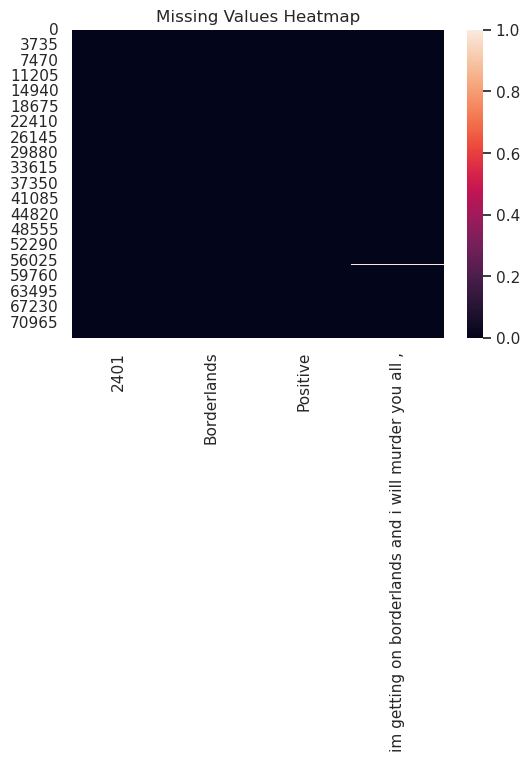

In [24]:
analyzer.summary()

# • Data Processing


•	**Problem1**:
Some rows in the dataset had missing tweet text in the `text` column


•	**Problem2**:
The dataset did not include a column for length words, which was essential for some analysis.

• **Problem 3**:There were duplicated rows which can effect the results of the analysis

• **Problem 4**: The `sentiment` column was different in some cases or extra spaces

• **Problem 5**: The original tweet text in `text` is not clean as it's contained URLs, mentions, special characters-etc which are not good for analysis

• **Problem 6**: The columns name's are unclear, Which make is harder to process,analysis,visualization 

# • Created a new column clean_text for the clean dataset Which is needed for the analysis and visualization 


In [25]:
analyzer.clean_dataset()

,id,entity,sentiment,text,clean_text
0,2401,Borderlands,positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
1,2401,Borderlands,positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,2401,Borderlands,positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,2401,Borderlands,positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
...,...,...,...,...,...
71341,9200,Nvidia,positive,Just realized that the Windows partition of my...,just realized that the windows partition of my...
71342,9200,Nvidia,positive,Just realized that my Mac window partition is ...,just realized that my mac window partition is ...
71343,9200,Nvidia,positive,Just realized the windows partition of my Mac ...,just realized the windows partition of my mac ...
71344,9200,Nvidia,positive,Just realized between the windows partition of...,just realized between the windows partition of...


# • Created two new columns 'length_all' and 'length_words' for calculate the length of the clean text.

In [26]:
analyzer.add_length()

,id,entity,sentiment,text,clean_text,length_all,length_words
0,2401,Borderlands,positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,50,12
1,2401,Borderlands,positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,49,10
2,2401,Borderlands,positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,50,10
3,2401,Borderlands,positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...,56,12
4,2401,Borderlands,positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...,52,10
...,...,...,...,...,...,...,...
71341,9200,Nvidia,positive,Just realized that the Windows partition of my...,just realized that the windows partition of my...,128,26
71342,9200,Nvidia,positive,Just realized that my Mac window partition is ...,just realized that my mac window partition is ...,116,23
71343,9200,Nvidia,positive,Just realized the windows partition of my Mac ...,just realized the windows partition of my mac ...,124,25
71344,9200,Nvidia,positive,Just realized between the windows partition of...,just realized between the windows partition of...,158,31


# • After we cleaned it we made sure it was clean and free of null values so we call summary method again 


🔹 Dataset Shape: (71346, 7)

🔹 Columns: ['id', 'entity', 'sentiment', 'text', 'clean_text', 'length_all', 'length_words']

🔹 First 5 Rows:
      id       entity sentiment  \
0  2401  Borderlands  positive   
1  2401  Borderlands  positive   
2  2401  Borderlands  positive   
3  2401  Borderlands  positive   
4  2401  Borderlands  positive   

                                                text  \
0  I am coming to the borders and I will kill you...   
1  im getting on borderlands and i will kill you ...   
2  im coming on borderlands and i will murder you...   
3  im getting on borderlands 2 and i will murder ...   
4  im getting into borderlands and i can murder y...   

                                          clean_text  length_all  length_words  
0  i am coming to the borders and i will kill you...          50            12  
1  im getting on borderlands and i will kill you all          49            10  
2  im coming on borderlands and i will murder you...          50          

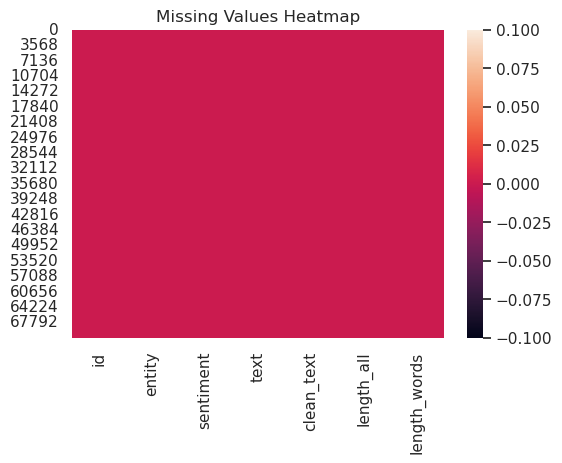

In [27]:
analyzer.summary()

# •  Data Analysis

In [28]:
analyzer.eda()

Sentiment distribution:
sentiment
negative      21611
positive      19649
neutral       17607
irrelevant    12479
Name: count, dtype: int64 

Top entities:
entity
TomClancysRainbowSix    2314
Verizon                 2310
CallOfDuty              2306
MaddenNFL               2305
NBA2K                   2297
WorldOfCraft            2294
Facebook                2286
LeagueOfLegends         2285
Microsoft               2282
TomClancysGhostRecon    2278
Name: count, dtype: int64 

Word frequency:
[('the', 43884), ('i', 28595), ('to', 28451), ('and', 26283), ('a', 23852), ('of', 19149), ('is', 17479), ('for', 15412), ('in', 15182), ('this', 14338)] 

Negative sentiment ratio per entity:
Borderlands : 0.19
CallOfDutyBlackopsColdWar : 0.24
Amazon : 0.25
Overwatch : 0.27
Xbox(Xseries) : 0.16
NBA2K : 0.63
Dota2 : 0.32
PlayStation5(PS5) : 0.19
WorldOfCraft : 0.14
CS-GO : 0.15
Google : 0.26
AssassinsCreed : 0.17
ApexLegends : 0.25
LeagueOfLegends : 0.27
Fortnite : 0.31
Microsoft : 0.32
Hearthstone

# •  Data visualization 

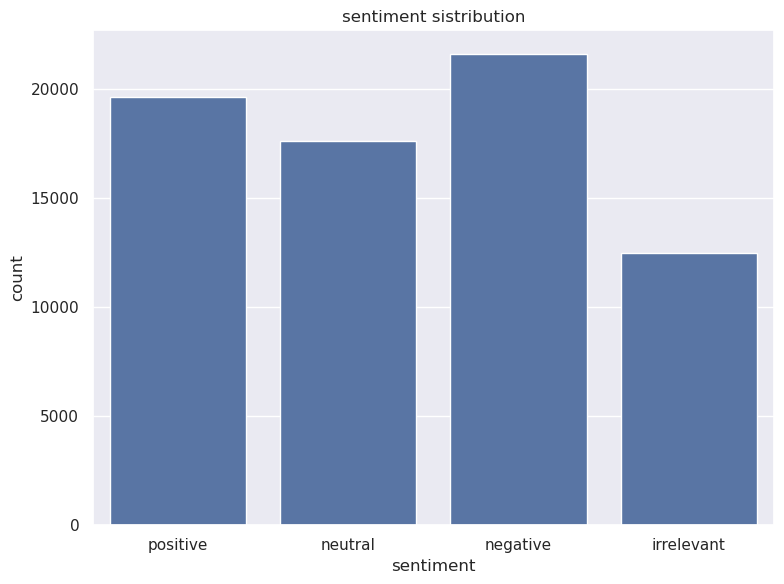

/tmp/ipykernel_169/79244886.py:260: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


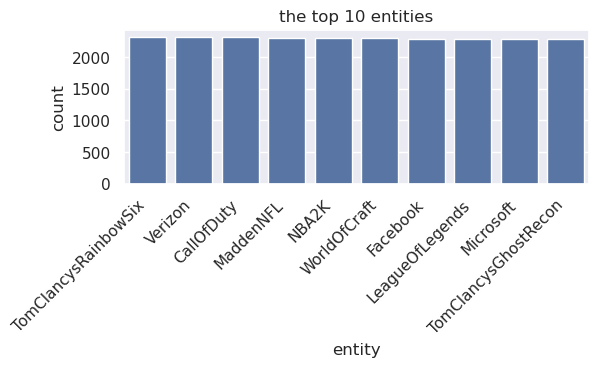

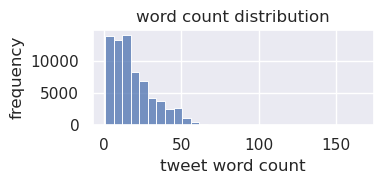

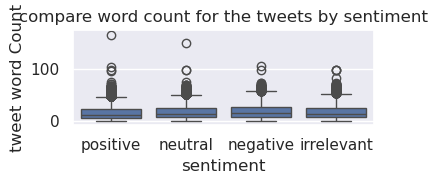

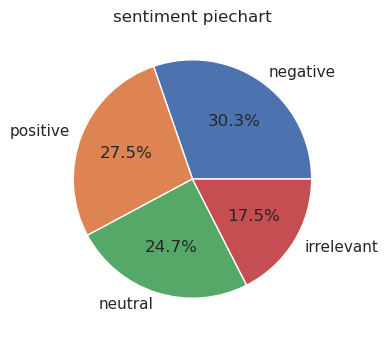

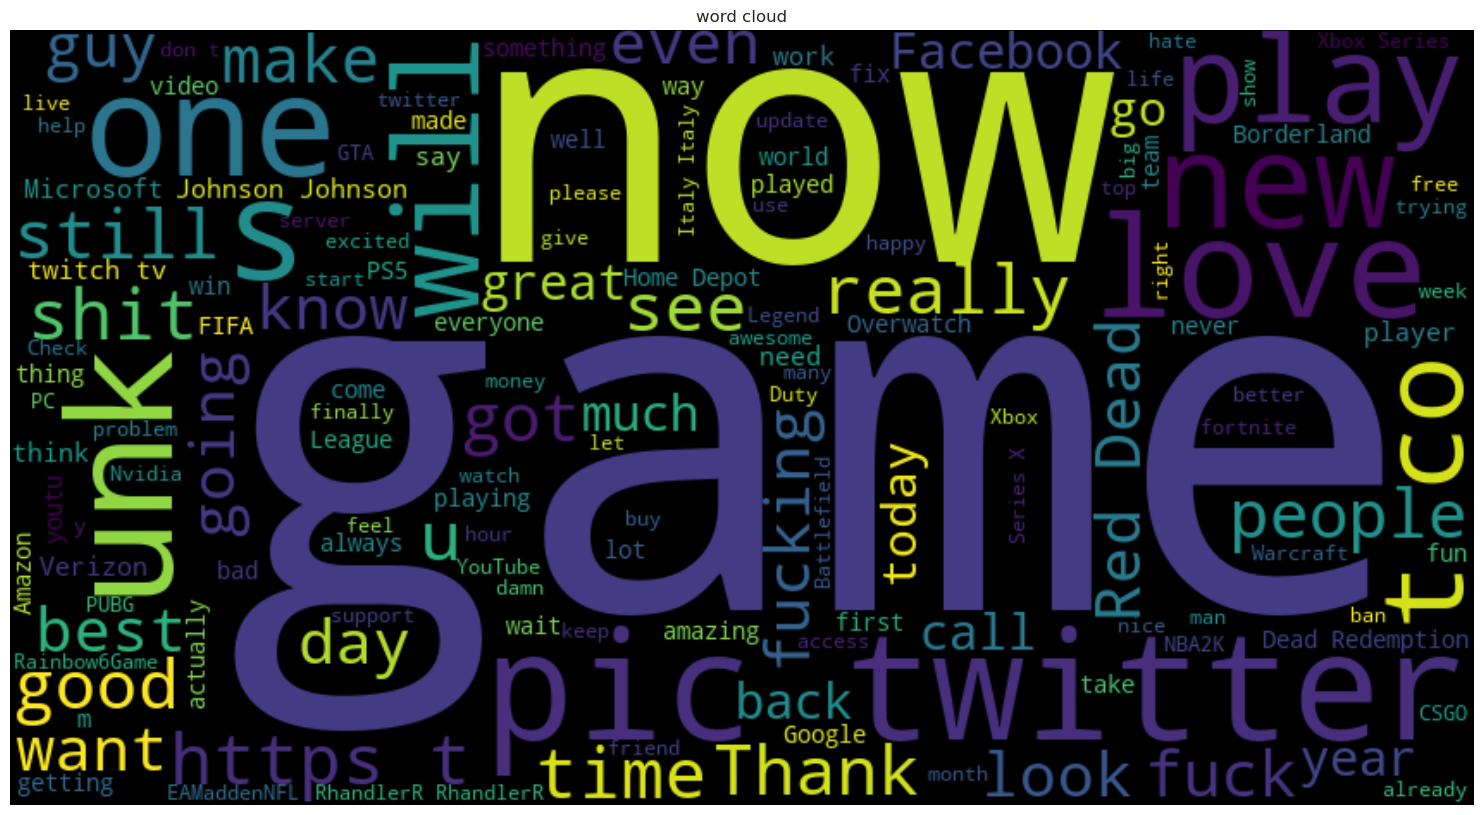

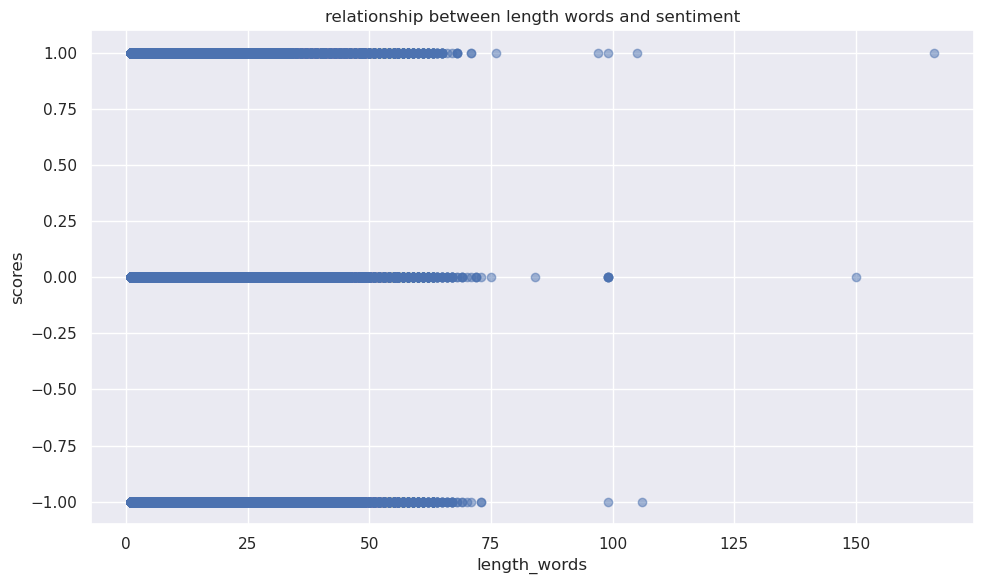

In [29]:
analyzer.visualize_all()